In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [ ]:
df = pd.read_csv("/content/code try.zip")
print("Dataset Loaded Successfully")
df.head()

Dataset Loaded Successfully


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [ ]:
print("\n Dataset Info:")
print(df.info())

print("\n Dataset Description:")
print(df.describe())


 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB
None

 Dataset Description:
            User ID         Age  EstimatedSalary   Purchased
count  4.000000e+02  400.000000       400.000000  400.000000
mean   1.569154e+07   37.655000     69742.500000    0.357500
std    7.165832e+04   10.482877     34096.960282    0.479864
min    1.556669e+07   18.000000     15000.000000    0.000000
25%    1.562676e+07   29.750000     43000.000000    0.000000
50%    1.569434e+07   37.000000     70000.000000    0.000000
75%    1.575036e+07   46.000000     88000.000000    1.00000

In [ ]:
print("\n🔍 Missing Values Check:")
print(df.isnull().sum())


🔍 Missing Values Check:
User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64


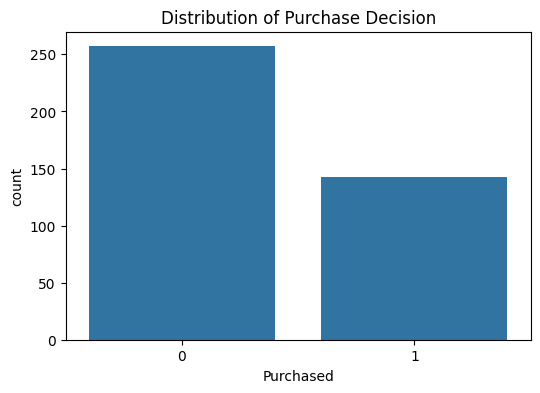

In [ ]:
# 🎯 Target Distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Purchased')
plt.title("Distribution of Purchase Decision")
plt.show()

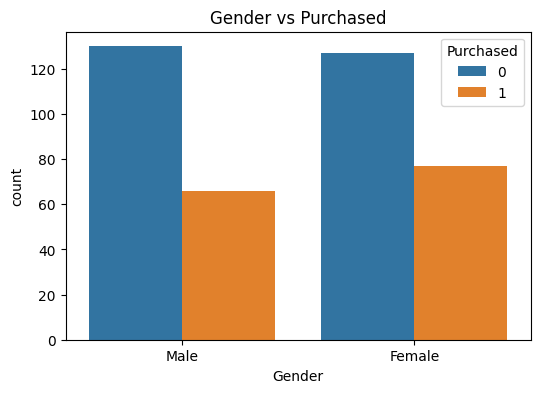

In [ ]:
# Gender-wise Purchase Comparison
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Gender', hue='Purchased')
plt.title("Gender vs Purchased")
plt.show()

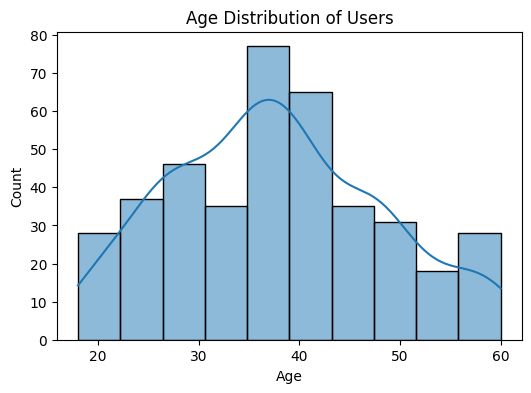

In [ ]:
# Age Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], kde=True)
plt.title("Age Distribution of Users")
plt.show()

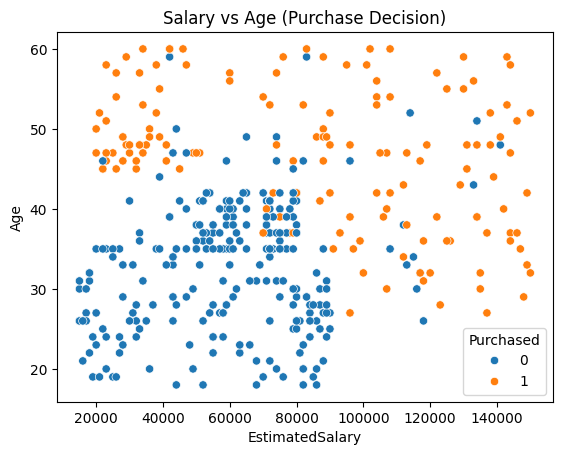

In [ ]:
# Income vs Purchase Decision
sns.scatterplot(data=df, x='EstimatedSalary', y='Age', hue='Purchased')
plt.title("Salary vs Age (Purchase Decision)")
plt.show()

/tmp/ipython-input-3041117264.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['Gender'], palette="Set2")


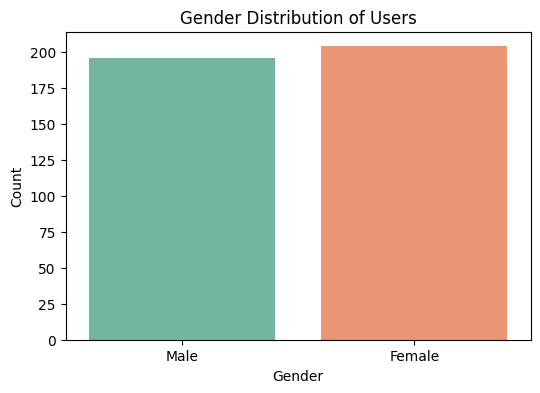

In [ ]:
# Gender Distribution
plt.figure(figsize=(6,4))
sns.countplot(x=df['Gender'], palette="Set2")
plt.title("Gender Distribution of Users")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

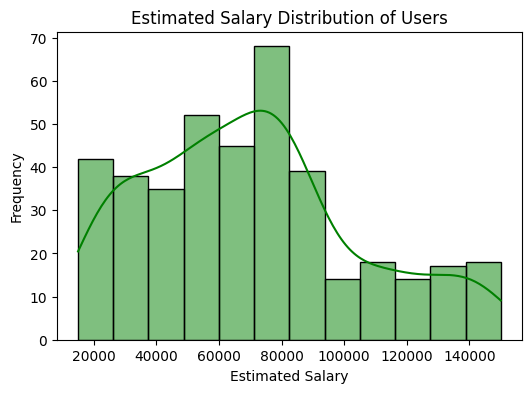

In [ ]:
# Salary Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['EstimatedSalary'], kde=True, color='green')
plt.title("Estimated Salary Distribution of Users")
plt.xlabel("Estimated Salary")
plt.ylabel("Frequency")
plt.show()

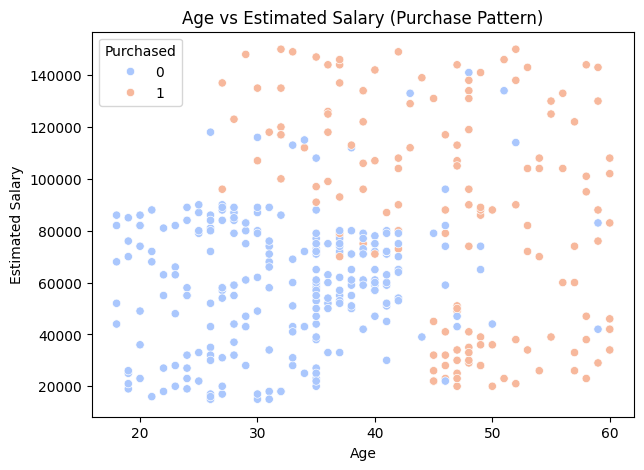

In [ ]:
# Age vs Salary vs Purchase
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x='Age', y='EstimatedSalary', hue='Purchased', palette="coolwarm")
plt.title("Age vs Estimated Salary (Purchase Pattern)")
plt.xlabel("Age")
plt.ylabel("Estimated Salary")
plt.show()

In [ ]:
X = df[['Age', 'EstimatedSalary']]
y = df['Purchased']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# 🎯 Logistic Regression
log = LogisticRegression()
log.fit(X_train, y_train)
y_pred_log = log.predict(X_test)

print("\n==============================")
print("📌 Logistic Regression Accuracy: ")
print(accuracy_score(y_test, y_pred_log) * 100)

print("\n📌 Logistic Regression Classification Report")
print("==============================")
print(classification_report(y_test, y_pred_log))


# 🌳 Decision Tree Classifier
tree = DecisionTreeClassifier()
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)

print("\n==============================")
print("📌 Decision Tree Accuracy: ")
print(accuracy_score(y_test, y_pred_tree) * 100)

print("\n📌 Decision Tree Classification Report")
print("==============================")
print(classification_report(y_test, y_pred_tree))


# 🌲 Random Forest Classifier
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\n==============================")
print("📌 Random Forest Accuracy: ")
print(accuracy_score(y_test, y_pred_rf) * 100)

print("\n📌 Random Forest Classification Report (Best Model)")
print("==============================")
print(classification_report(y_test, y_pred_rf))


📌 Logistic Regression Accuracy: 
86.0

📌 Logistic Regression Classification Report
              precision    recall  f1-score   support

           0       0.84      0.97      0.90        63
           1       0.93      0.68      0.78        37

    accuracy                           0.86       100
   macro avg       0.88      0.82      0.84       100
weighted avg       0.87      0.86      0.85       100


📌 Decision Tree Accuracy: 
82.0

📌 Decision Tree Classification Report
              precision    recall  f1-score   support

           0       0.85      0.87      0.86        63
           1       0.77      0.73      0.75        37

    accuracy                           0.82       100
   macro avg       0.81      0.80      0.80       100
weighted avg       0.82      0.82      0.82       100


📌 Random Forest Accuracy: 
89.0

📌 Random Forest Classification Report (Best Model)
              precision    recall  f1-score   support

           0       0.93      0.89      0.91       

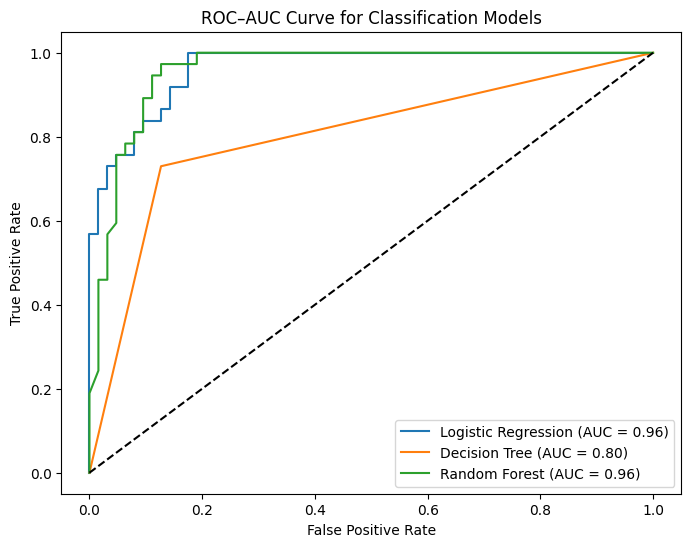

In [ ]:
# ============================================================
# 📌 ROC–AUC Curve for All Models
# ============================================================

from sklearn.metrics import roc_curve, auc

# Getting prediction probabilities
log_prob = log.predict_proba(X_test)[:,1]
tree_prob = tree.predict_proba(X_test)[:,1]
rf_prob = rf.predict_proba(X_test)[:,1]

# Calculating ROC values
fpr_log, tpr_log, _ = roc_curve(y_test, log_prob)
fpr_tree, tpr_tree, _ = roc_curve(y_test, tree_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)

auc_log = auc(fpr_log, tpr_log)
auc_tree = auc(fpr_tree, tpr_tree)
auc_rf = auc(fpr_rf, tpr_rf)

# Plotting ROC Curve
plt.figure(figsize=(8,6))
plt.plot(fpr_log, tpr_log, label=f"Logistic Regression (AUC = {auc_log:.2f})")
plt.plot(fpr_tree, tpr_tree, label=f"Decision Tree (AUC = {auc_tree:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})")

# Random line
plt.plot([0,1], [0,1], 'k--')

# Title & labels
plt.title("ROC–AUC Curve for Classification Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()